<a href="https://colab.research.google.com/github/suyogbastakoti/Ai-and-Ml-Module/blob/main/2407093_SuyogBastakoti_Worksheet1_AI%26ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WORKSHEET 1**

**Step 1: Read and Display the Image**

(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

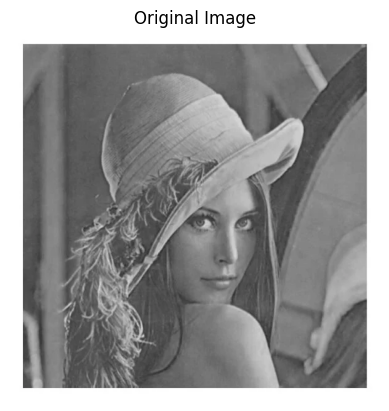

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Open image name
img = Image.open("/content/drive/MyDrive/Data Set /lenagray.png")

# Display image
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

**Step 2: Display Top Left 100×100 Pixels**

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

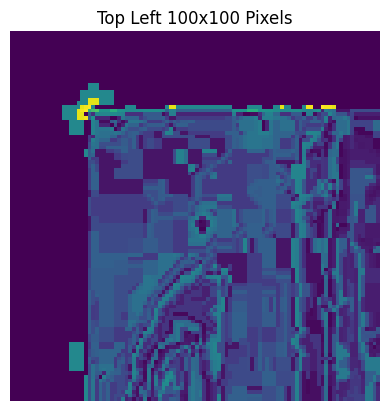

In [ ]:
img_array = np.array(img)

# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")

**Step 3: Show R, G, B Channels**

In [ ]:
print(img_array.shape)

(600, 600)


**Convert Image to RGB (Fix)**

In [ ]:
img = Image.open("/content/drive/MyDrive/Data Set /lenagray.png").convert("RGB")
img_array = np.array(img)

In [ ]:
print(img_array.shape)

(600, 600, 3)


**Run the Channel Code**

(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

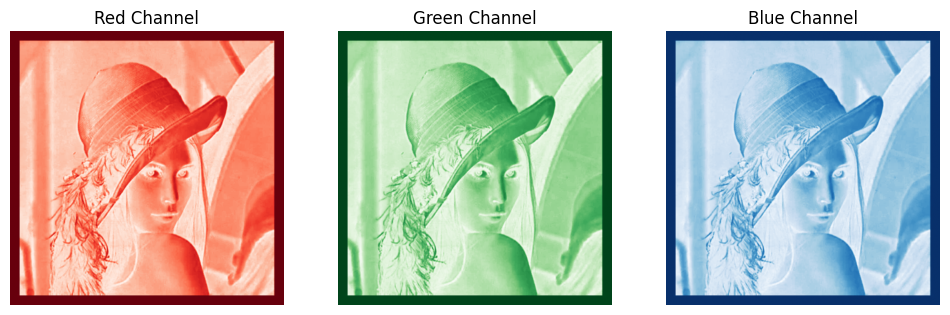

In [ ]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

**Modify Top Left 100×100 Pixels to 210**

(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

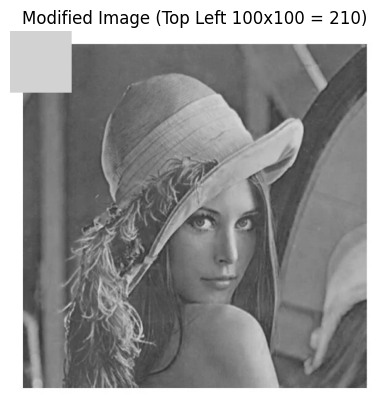

In [ ]:
modified_img = img_array.copy()

# Set top-left 100x100 pixels to 210
modified_img[0:100, 0:100] = 210

plt.imshow(modified_img)
plt.title("Modified Image (Top Left 100x100 = 210)")
plt.axis("off")

**Exercise- 2**

**Complete all the Task.**

. Load and display a grayscale image.


• Load a grayscale image using the Pillow library.

• Display the grayscale image using matplotlib.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

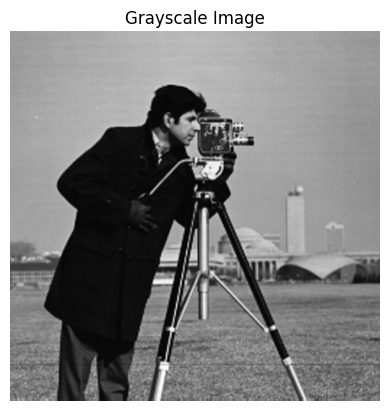

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/Data Set /cameraman.png").convert("L")

# Convert to numpy array
img_array = np.array(img)

# Display image
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

**Step 2: Extract Middle 150×150 Pixels**

(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

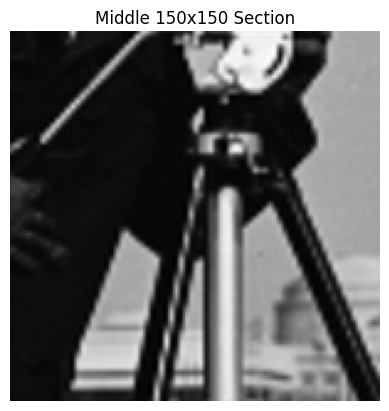

In [ ]:
height, width = img_array.shape

center_y = height // 2
center_x = width // 2

middle_section = img_array[center_y-75:center_y+75, center_x-75:center_x+75]

plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")

**Step 3: Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).**

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

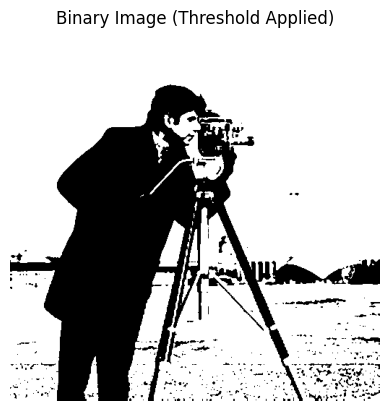

In [ ]:
binary_img = img_array.copy()

binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

plt.imshow(binary_img, cmap='gray')
plt.title("Binary Image (Threshold Applied)")
plt.axis("off")

**Step 4: Rotate Image 90° Clockwise**

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

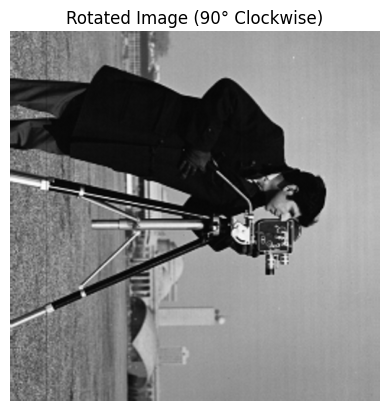

In [ ]:
rotated_img = img.rotate(-90)

plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")

**Step 5: Convert Grayscale Image to RGB**

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

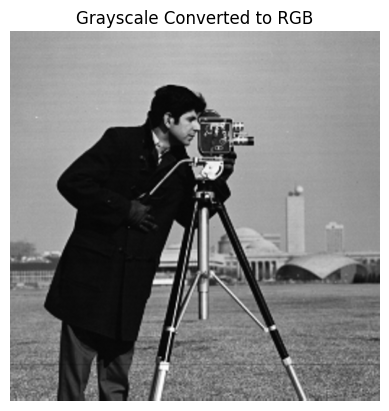

In [ ]:
rgb_image = np.stack((img_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")

In [ ]:
print(img_array.shape)

(512, 512)


**3 Image Compression and Decompression using PCA**

**Step 1: Load Image and Convert to Grayscale**

We use Pillow + NumPy.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

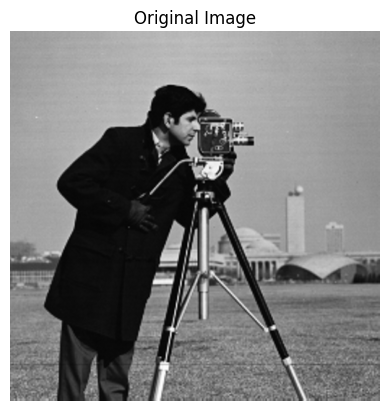

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/Data Set /cameraman.png").convert("L")  # convert to grayscale
img_array = np.array(img)

plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")

**Step 2: Standardize / Center the Data**

For PCA we must center the dataset (subtract mean).

In [ ]:
# convert to float
X = img_array.astype(float)

# mean of each column
mean = np.mean(X, axis=0)

# center data
X_centered = X - mean

Explanation:

X_centered = X − mean

This makes the dataset mean = 0.

**Step 3: Compute Covariance Matrix**

In [ ]:
cov_matrix = np.cov(X_centered, rowvar=False)

Explanation:

Covariance formula:

Cov = (Xᵀ X) / (n-1)

**Step 4: Eigenvalues and Eigenvectors**

In [ ]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

Explanation:

Eigenvalues → importance of components

Eigenvectors → directions of maximum variance

**Step 5: Sort Eigenvalues (Descending Order)**

In [ ]:
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalues = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

**Step 6: Cumulative Explained Variance Plot**

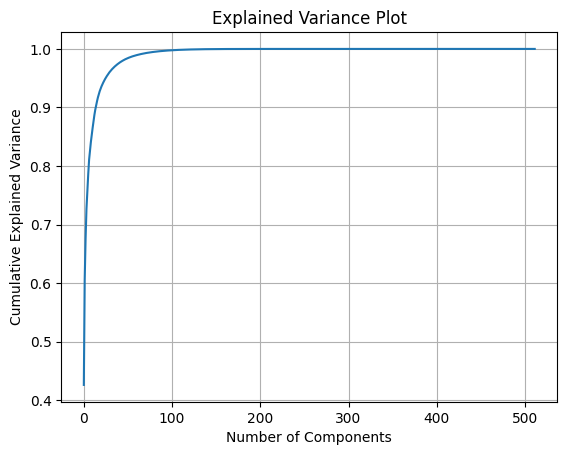

In [ ]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()

This plot helps choose k principal components.

Example:

90% variance

95% variance

99% variance

**Step 7: Image Compression (Projection)**

In [ ]:
k = 50

PC = sorted_eigenvectors[:, :k]

compressed = np.dot(X_centered, PC)

**Step 8: Reconstruction (Decompression)**

**Rebuild the image: **

In [ ]:
reconstructed = np.dot(compressed, PC.T) + mean

**Step 9: Display Reconstructed Image**

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

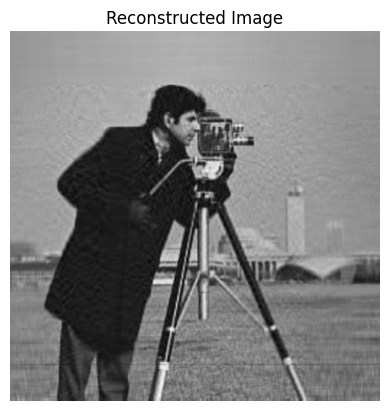

In [ ]:
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")

**Step 10: Experiments (4 Different PCA Values)**

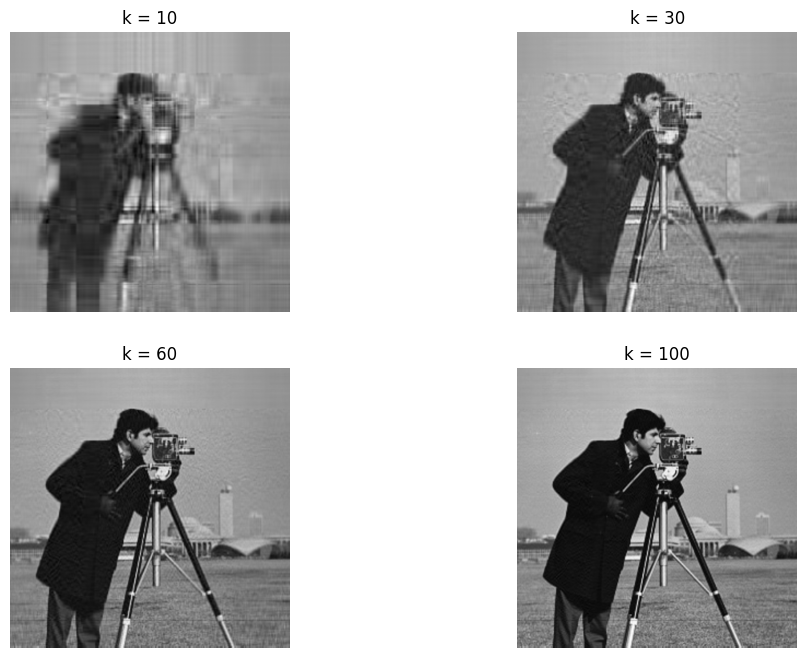

In [ ]:
ks = [10, 30, 60, 100]

plt.figure(figsize=(12,8))

for i,k in enumerate(ks):

    PC = sorted_eigenvectors[:, :k]
    compressed = np.dot(X_centered, PC)
    reconstructed = np.dot(compressed, PC.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()

**Overall Evaluation**

PCA reduces the size of the image data by keeping only the most important features (principal components). When we use more principal components, the reconstructed image looks more similar to the original image. When we use fewer components, the image is more compressed but the quality becomes lower.

**Overall PCA Workflow**


Image

 ↓

Convert to grayscale

 ↓

Center data

 ↓

Covariance matrix

 ↓

Eigenvalues & Eigenvectors

 ↓

Select top k components

 ↓

Compress image

 ↓

Reconstruct image